In [ ]:
import kagglehub
path = kagglehub.dataset_download("shubh0799/churn-modelling")
print(path)

100%|██████████| 262k/262k [00:00<00:00, 53.0MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/shubh0799/churn-modelling/versions/1


In [ ]:
import pandas as pd
import os

path = '/root/.cache/kagglehub/datasets/shubh0799/churn-modelling/versions/1'

print(os.listdir(path))

['Churn_Modelling.csv']


In [ ]:
# CSV load
df = pd.read_csv(path + '/Churn_Modelling.csv')

# Naya naam se save
df.to_csv('bank_customer_analysis_raw.csv', index=False)

print("File save ho gayi: bank_customer_analysis_raw.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

File save ho gayi: bank_customer_analysis_raw.csv
Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

First 5 rows:
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1      

In [ ]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


**SQL**

In [ ]:
import pandas as pd
import sqlite3

df = pd.read_csv('bank_customer_analysis_raw.csv')

conn = sqlite3.connect('bank_customers.db')

df.to_sql('customers', conn, if_exists='replace', index=False)

print(f"Total rows: {len(df)}")

test = pd.read_sql("SELECT * FROM customers LIMIT 5", conn)
print(test)

Total rows: 10000
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63      

In [ ]:
q1 = pd.read_sql("""
    SELECT
        Exited,
        COUNT(*) as total_customers,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
    FROM customers
    GROUP BY Exited
    ORDER BY Exited
""", conn)

print(" Overall exit Rate:")
print(q1)

 Overall exit Rate:
   Exited  total_customers  percentage
0       0             7963       79.63
1       1             2037       20.37


In [ ]:
q2 = pd.read_sql("""
    SELECT
        Geography,
        COUNT(*) as total_customers,
        SUM(Exited) as exited,
        ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as exit_rate
    FROM customers
    GROUP BY Geography
    ORDER BY exit_rate DESC
""", conn)

print(" Geography wise exit:")
print(q2)

 Geography wise exit:
  Geography  total_customers  exited  exit_rate
0   Germany             2509     814      32.44
1     Spain             2477     413      16.67
2    France             5014     810      16.15


In [ ]:
q3 = pd.read_sql("""
    SELECT
        CASE
            WHEN Age < 30 THEN 'Under 30'
            WHEN Age BETWEEN 30 AND 40 THEN '30-40'
            WHEN Age BETWEEN 41 AND 50 THEN '41-50'
            WHEN Age BETWEEN 51 AND 60 THEN '51-60'
            ELSE 'Above 60'
        END as age_group,
        COUNT(*) as total,
        SUM( case when Exited = 1 then "1" else "0" end)  as exited,
        ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as exit_rate
    FROM customers
    GROUP BY age_group
    ORDER BY exit_rate DESC
""", conn)

print("Age Group wise exit:")
print(q3)

Age Group wise exit:
  age_group  total  exited  exit_rate
0     51-60    797     448      56.21
1     41-50   2320     788      33.97
2  Above 60    464     115      24.78
3     30-40   4778     562      11.76
4  Under 30   1641     124       7.56


In [ ]:
q4 = pd.read_sql("""
    SELECT
      Geography ,
        CASE
            WHEN CreditScore < 500 THEN 'Poor (< 500)'
            WHEN CreditScore BETWEEN 500 AND 599 THEN 'Fair (500-599)'
            WHEN CreditScore BETWEEN 600 AND 699 THEN 'Good (600-699)'
            WHEN CreditScore BETWEEN 700 AND 799 THEN 'Very Good (700-799)'
            ELSE 'Excellent (800+)'
        END as credit_group,
        COUNT(*) as total,
        SUM(Exited) as exited,
        ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as exit_rate
    FROM customers
    GROUP BY credit_group , Geography
    ORDER BY exit_rate DESC
""", conn)

print("Credit Score wise exit:")
print(q4)

Credit Score wise exit:
   Geography         credit_group  total  exited  exit_rate
0    Germany         Poor (< 500)    172      61      35.47
1    Germany       Fair (500-599)    588     203      34.52
2    Germany  Very Good (700-799)    633     213      33.65
3    Germany       Good (600-699)    940     285      30.32
4    Germany     Excellent (800+)    176      52      29.55
5     France         Poor (< 500)    327      64      19.57
6      Spain         Poor (< 500)    133      25      18.80
7      Spain       Fair (500-599)    610     105      17.21
8     France       Fair (500-599)   1204     202      16.78
9      Spain  Very Good (700-799)    615     103      16.75
10     Spain     Excellent (800+)    156      26      16.67
11    France       Good (600-699)   1915     314      16.40
12     Spain       Good (600-699)    963     154      15.99
13    France     Excellent (800+)    323      50      15.48
14    France  Very Good (700-799)   1245     180      14.46


In [ ]:
q5 = pd.read_sql("""
    SELECT
    Geography,
        CASE
            WHEN Balance = 0 THEN 'Zero Balance'
            WHEN Balance < 50000 THEN 'Low (< 50K)'
            WHEN Balance BETWEEN 50000 AND 100000 THEN 'Medium (50K-100K)'
            WHEN Balance BETWEEN 100000 AND 150000 THEN 'High (100K-150K)'
            ELSE 'Very High (150K+)'
        END as balance_group,
        COUNT(*) as total,
        SUM(Exited) as exited,
        ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as exit_rate,
        ROUND(AVG(Balance), 2) as avg_balance
    FROM customers
    GROUP BY balance_group , Geography
    ORDER BY exit_rate DESC
""", conn)

print(" Balance wise exit:")
print(q5)

# 2 strong insights:
# Low balance customers France aur Spain mein sabse zyada exit kar rahe hain — inke paas invest karne ko kuch nahi, isliye bank chhod rahe hain
# Germany mein High balance customers 39% exit kar rahe hain — ye alarming hai. Zyada paisa wale customers Germany mein bank chhod rahe hain — revenue loss zyada hoga

 Balance wise exit:
   Geography      balance_group  total  exited  exit_rate  avg_balance
0     France        Low (< 50K)     41      20      48.78     40748.21
1      Spain        Low (< 50K)     15       6      40.00     35924.69
2    Germany   High (100K-150K)   1652     646      39.10    123211.65
3      Spain  Very High (150K+)    223      59      26.46    168731.84
4     France  Very High (150K+)    432     105      24.31    167562.21
5      Spain  Medium (50K-100K)    338      82      24.26     83409.86
6    Germany  Medium (50K-100K)    524     108      20.61     84970.23
7    Germany  Very High (150K+)    314      60      19.11    164279.61
8     France  Medium (50K-100K)    647     110      17.00     83212.58
9     France   High (100K-150K)   1476     238      16.12    124279.40
10     Spain   High (100K-150K)    702     103      14.67    123596.80
11    France       Zero Balance   2418     337      13.94         0.00
12     Spain       Zero Balance   1199     163      13.59

In [ ]:
q6 = pd.read_sql("""
    SELECT
        CASE WHEN IsActiveMember = 1 THEN 'Active' ELSE 'Inactive' END as member_status,
        COUNT(*) as total,
        SUM(Exited) as exited,
        ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as exit_rate
    FROM customers
    GROUP BY IsActiveMember
    ORDER BY exit_rate DESC
""", conn)

print(" Active vs Inactive exit:")
print(q6)

 Active vs Inactive exit:
  member_status  total  exited  exit_rate
0      Inactive   4849    1302      26.85
1        Active   5151     735      14.27


In [ ]:
q7 = pd.read_sql("""
    SELECT
        NumOfProducts,
        COUNT(*) as total,
        SUM(Exited) as exied ,
        ROUND(SUM(Exited) * 100.0 / COUNT(*), 2) as exit_rate,
        ROUND(AVG(Balance), 2) as avg_balance
    FROM customers
    GROUP BY NumOfProducts
    ORDER BY NumOfProducts
""", conn)

print(" Products vs Churn:")
print(q7)

# Business recommendation: Bank ko 2 products pe focus karna chahiye — sweet spot yahi hai.

 Products vs Churn:
   NumOfProducts  total  exied  exit_rate  avg_balance
0              1   5084   1409      27.71     98551.87
1              2   4590    348       7.58     51879.15
2              3    266    220      82.71     75458.33
3              4     60     60     100.00     93733.14


In [ ]:
q8 = pd.read_sql("""
    SELECT
        CustomerId,
        Geography,
        Gender,
        Age,
        Balance,
        NumOfProducts,
        IsActiveMember,
        Exited
    FROM customers
    WHERE
        Exited = 1
        AND Balance > 100000
        AND Age BETWEEN 41 AND 60
    ORDER BY Balance DESC
    LIMIT 20
""", conn)

print(" High Value exited Customers:")
print(q8)

 High Value exited Customers:
    CustomerId Geography  Gender  Age    Balance  NumOfProducts  \
0     15715622    France  Female   57  238387.56              1   
1     15714241     Spain    Male   42  222267.63              1   
2     15586674     Spain  Female   58  216109.88              1   
3     15594408     Spain  Female   48  213146.20              1   
4     15721658     Spain  Female   56  209767.31              2   
5     15673020    France  Female   49  204510.94              1   
6     15620756    France    Male   49  202904.64              1   
7     15689514    France    Male   43  201696.07              1   
8     15793688    France    Male   50  201009.64              1   
9     15648489    France    Male   53  199689.49              1   
10    15725665    France    Male   47  198546.10              2   
11    15599329    France  Female   49  195238.29              4   
12    15617065     Spain    Male   42  194532.66              1   
13    15606115    France  Female

In [ ]:
revenue_risk = pd.read_sql("""
    SELECT
        NumOfProducts,
        COUNT(*) as high_value_churned,
        ROUND(SUM(Balance), 2) as total_balance_lost,
        ROUND(AVG(Balance), 2) as avg_balance_lost
    FROM customers
    WHERE
        Exited = 1
        AND Balance > 100000
        AND Age BETWEEN 41 AND 60
    GROUP BY NumOfProducts
    ORDER BY total_balance_lost DESC
""", conn)

print("Revenue at Risk by Product:")
print(revenue_risk)

Revenue at Risk by Product:
   NumOfProducts  high_value_churned  total_balance_lost  avg_balance_lost
0              1                 512         67566595.97         131966.01
1              2                 111         14573700.31         131294.60
2              3                  69          8822554.16         127863.10
3              4                  26          3424808.81         131723.42


In [ ]:
with pd.ExcelWriter('bank_sql_results.xlsx') as writer:
    q1.to_excel(writer, sheet_name='1_Overall_exit', index=False)
    q2.to_excel(writer, sheet_name='2_Geography', index=False)
    q3.to_excel(writer, sheet_name='3_Age_Group', index=False)
    q4.to_excel(writer, sheet_name='4_Credit_Score', index=False)
    q5.to_excel(writer, sheet_name='5_Balance', index=False)
    q6.to_excel(writer, sheet_name='6_Active_Members', index=False)
    q7.to_excel(writer, sheet_name='7_Products', index=False)
    q8.to_excel(writer, sheet_name='8_High_Value', index=False)
    revenue_risk.to_excel(writer, sheet_name='Revenue_At_Risk', index=False)

print(" complete — insight ")
conn.close()

 complete — insight 


**EDA**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank_customer_analysis_raw.csv')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 150

print("Shape:", df.shape)
print("\nExited distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean()*100:.2f}%")

Shape: (10000, 14)

Exited distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


In [ ]:
# RowNumber, CustomerId, Surname kaam ke nahi h
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Age groups — EDA ke liye useful
df['age_group'] = pd.cut(df['Age'],
                          bins=[0, 30, 40, 50, 60, 100],
                          labels=['Under 30', '30-40', '41-50', '51-60', 'Above 60'])

# Balance groups
df['balance_group'] = pd.cut(df['Balance'],
                              bins=[-1, 0, 50000, 100000, 150000, 300000],
                              labels=['Zero', 'Low', 'Medium', 'High', 'Very High'])

df.to_csv('bank_customer_clean.csv', index=False)
print("Columns after cleaning:")
print(df.columns.tolist())
print("\nAge group distribution:")
print(df['age_group'].value_counts().sort_index())

Columns after cleaning:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'age_group', 'balance_group']

Age group distribution:
age_group
Under 30    1968
30-40       4451
41-50       2320
51-60        797
Above 60     464
Name: count, dtype: int64


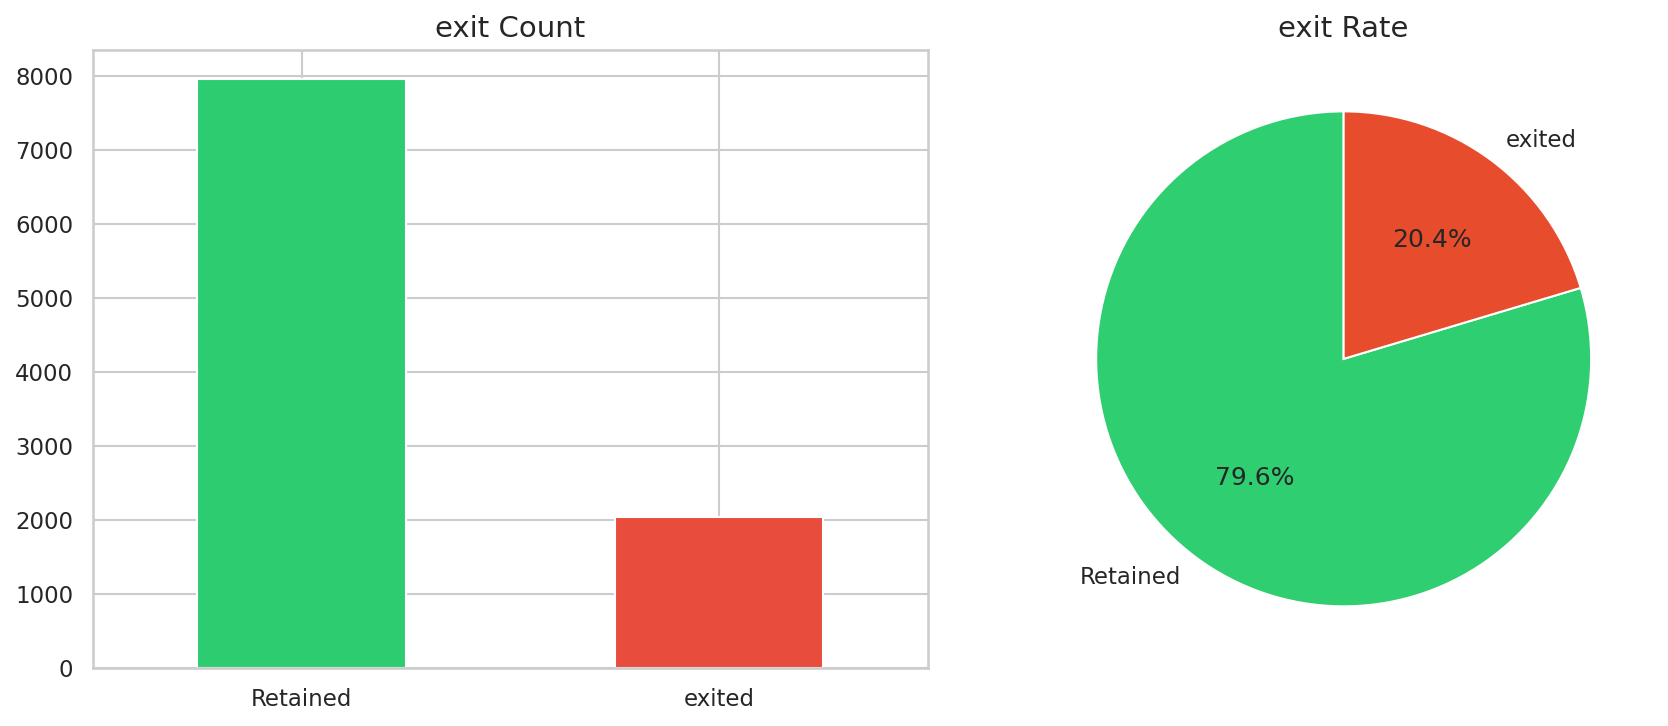

Chart 1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Exited'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white'

)
axes[0].set_title('exit Count', fontsize=14)
axes[0].set_xticklabels(['Retained', 'exited'], rotation=0)
axes[0].set_xlabel('')

df['Exited'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Retained', 'exited'],
    colors=['#2ece71', '#e74c2c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('exit Rate', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('b_chart1_exit_overview.png', bbox_inches='tight')
plt.show()
print("Chart 1")

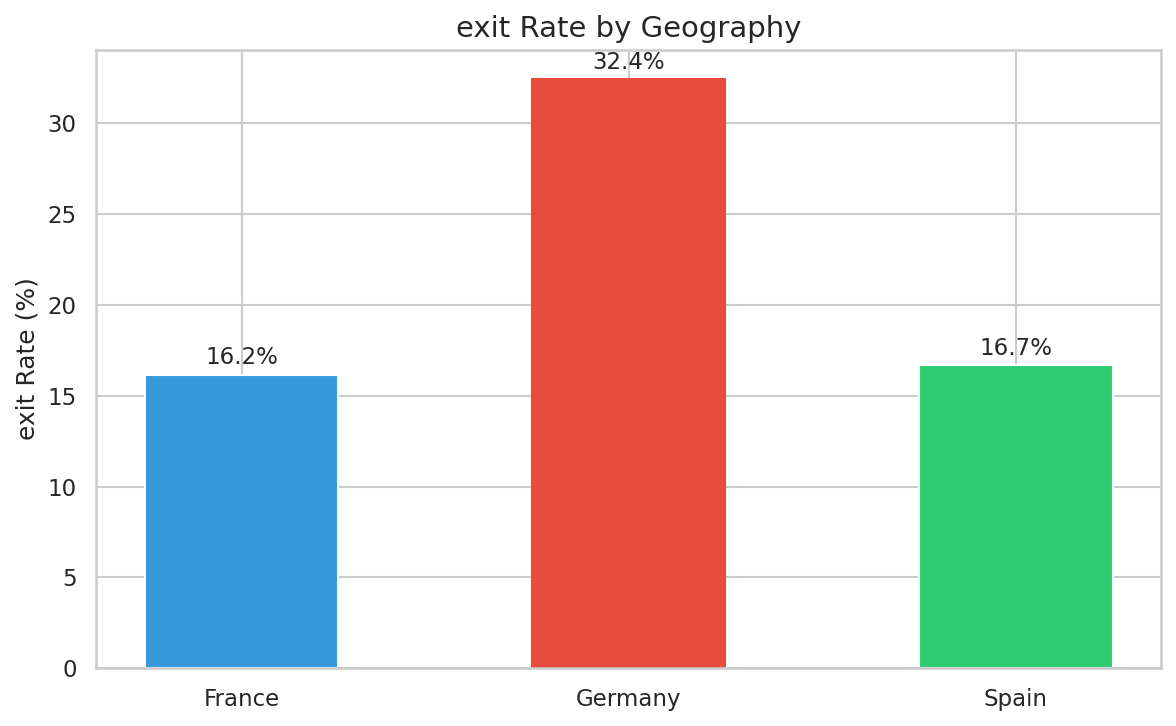

Chart 2 


In [ ]:
geo_stats = df.groupby('Geography')['Exited'].mean() * 100
geo_stats = geo_stats.reset_index()
geo_stats.columns = ['Geography', 'exit_rate']

plt.figure(figsize=(8, 5))
bars = plt.bar(geo_stats['Geography'], geo_stats['exit_rate'],
               color=['#3498db', '#e74c3c', '#2ecc71'],
               edgecolor='white', width=0.5)

max_idx = geo_stats['exit_rate'].idxmax()
bars[max_idx].set_color('#e74c3c')

for bar, val in zip(bars, geo_stats['exit_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.title('exit Rate by Geography', fontsize=14)
plt.ylabel('exit Rate (%)')
plt.tight_layout()
plt.savefig('b_chart2_geography.png', bbox_inches='tight')
plt.show()
print("Chart 2 ")

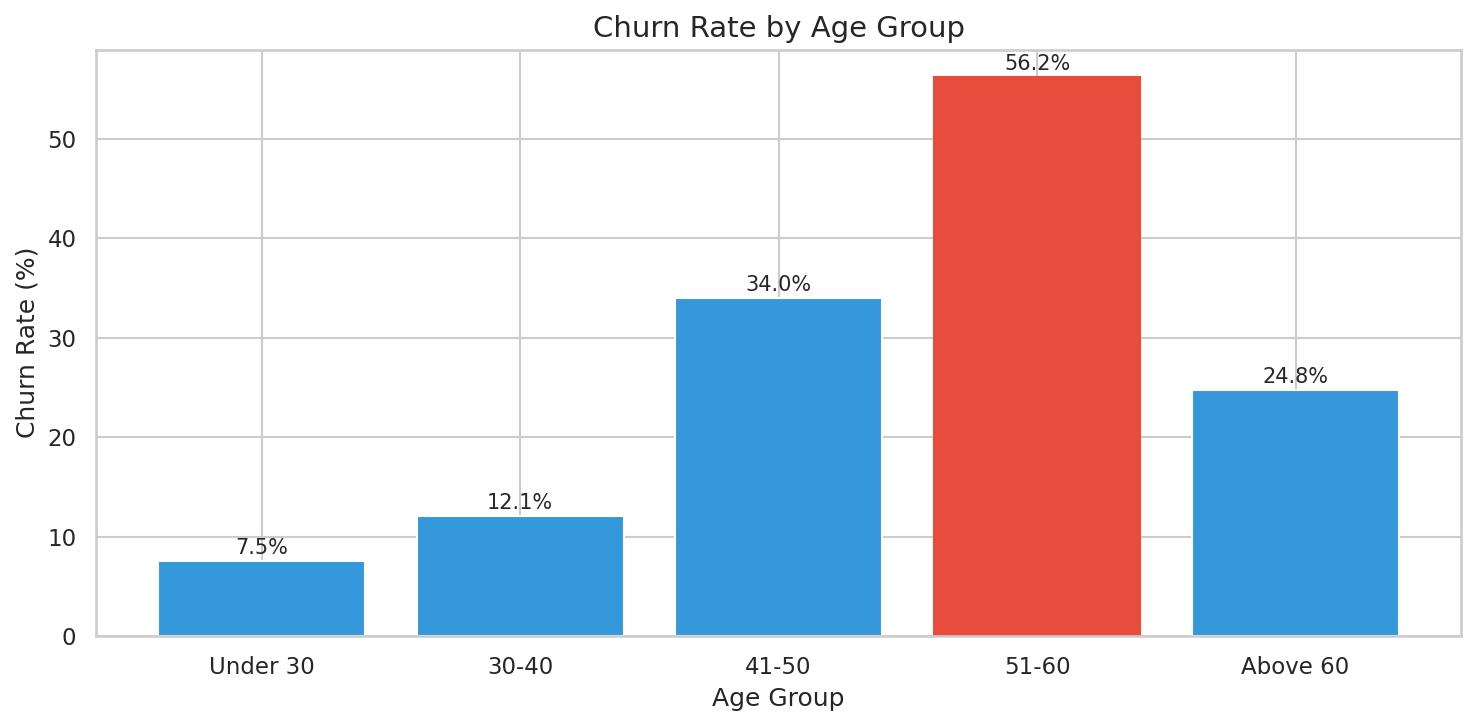

Chart 3 


In [ ]:
age_stats = df.groupby('age_group', observed=True)['Exited'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(age_stats.index, age_stats.values,
               color='#3498db', edgecolor='white')

max_idx = age_stats.values.argmax()
bars[max_idx].set_color('#e74c3c')

for bar, val in zip(bars, age_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Churn Rate by Age Group', fontsize=14)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Age Group')
plt.tight_layout()
plt.savefig('b_chart3_age_group.png', bbox_inches='tight')
plt.show()
print("Chart 3 ")

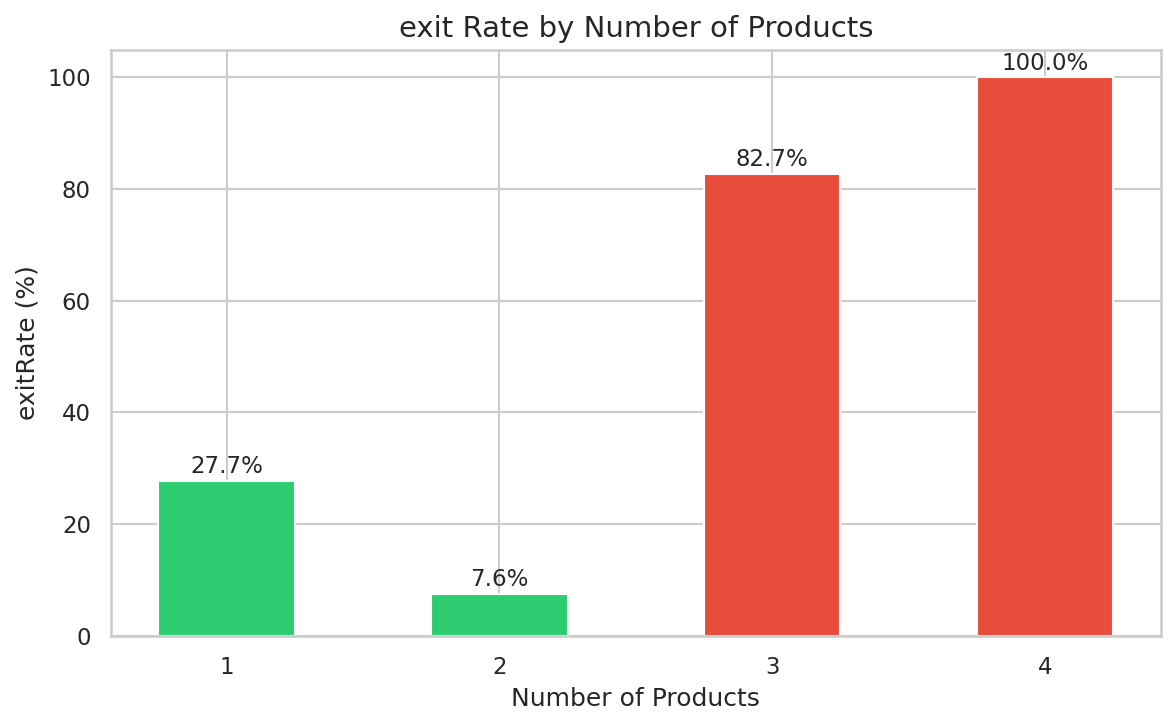

Chart 4 


In [ ]:

prod_stats = df.groupby('NumOfProducts')['Exited'].mean() * 100

plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#2ecc71', '#e74c3c', '#e74c3c']
bars = plt.bar(prod_stats.index, prod_stats.values,
               color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, prod_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

plt.title('exit Rate by Number of Products', fontsize=14)
plt.xlabel('Number of Products')
plt.ylabel('exitRate (%)')
plt.xticks([1, 2, 3, 4])
plt.tight_layout()
plt.savefig('b_chart4_products.png', bbox_inches='tight')
plt.show()
print("Chart 4 ")

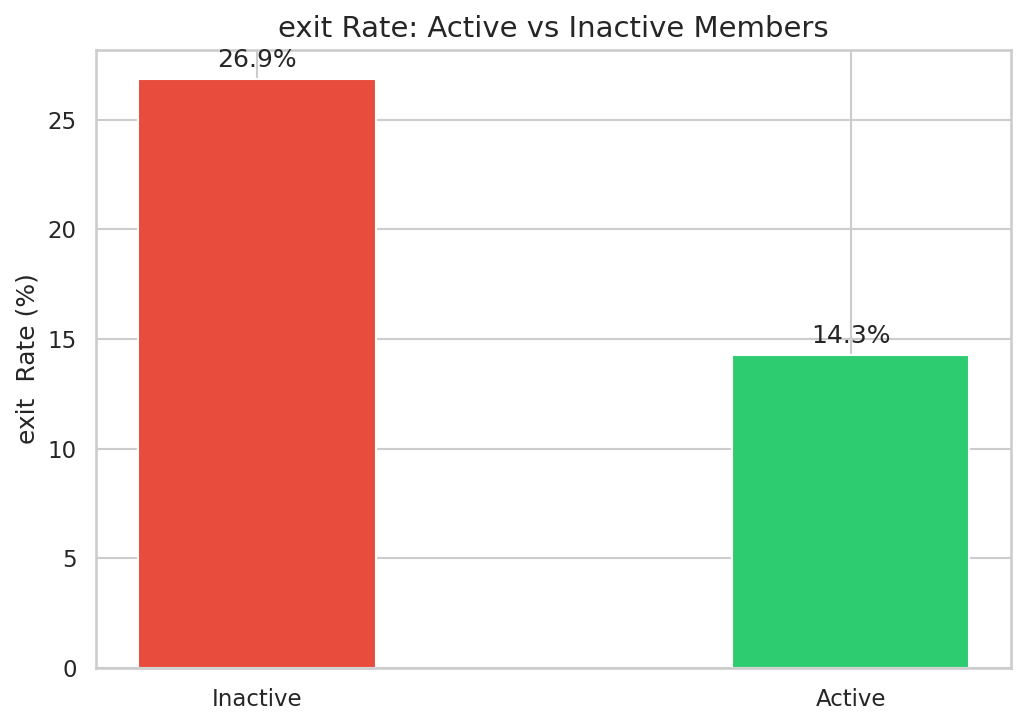

Chart 5 


In [ ]:
# Active vs Inactive
active_stats = df.groupby('IsActiveMember')['Exited'].mean() * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(['Inactive', 'Active'], active_stats.values,
               color=['#e74c3c', '#2ecc71'],
               edgecolor='white', width=0.4)

for bar, val in zip(bars, active_stats.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=12)

plt.title('exit Rate: Active vs Inactive Members', fontsize=14)
plt.ylabel('exit  Rate (%)')
plt.tight_layout()
plt.savefig('b_chart5_active_members.png', bbox_inches='tight')
plt.show()
print("Chart 5 ")

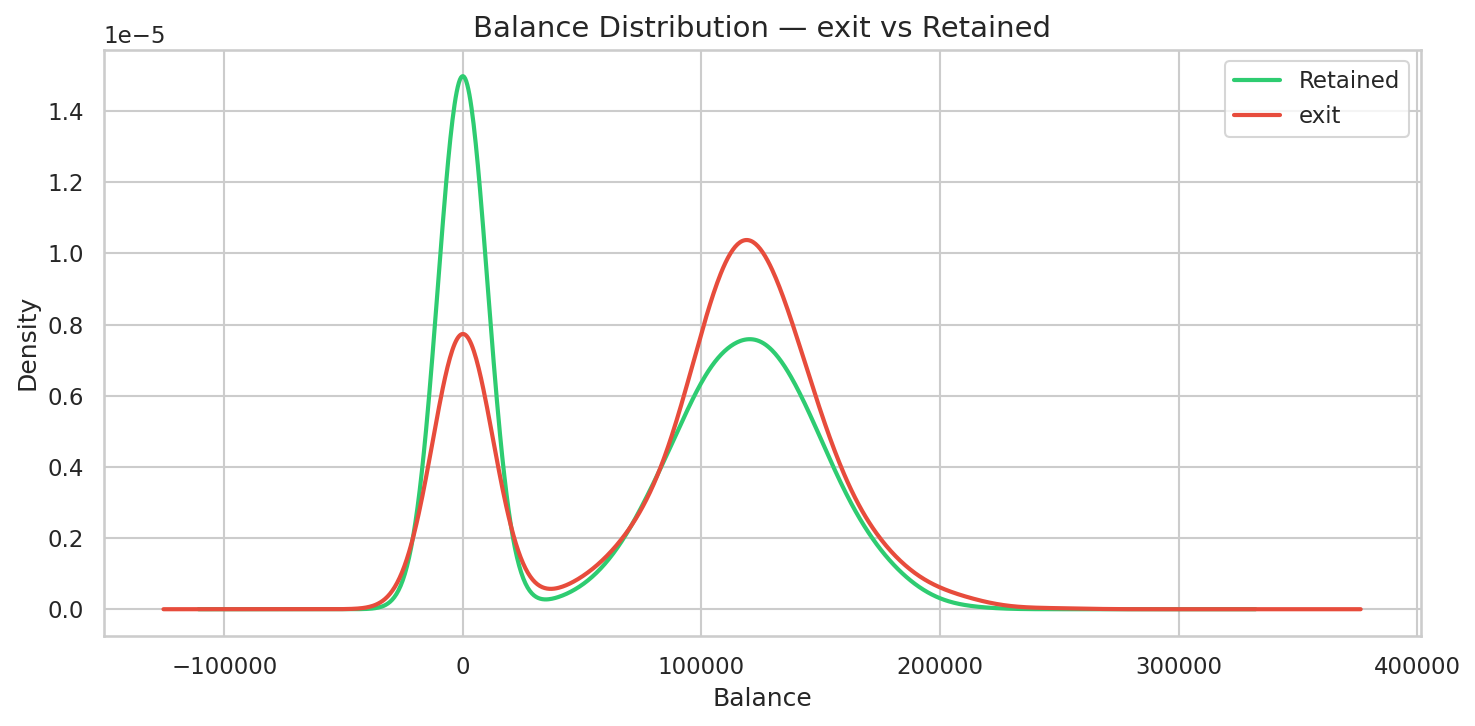

Chart 6 


In [ ]:
# Distribution — exit vs Retained
plt.figure(figsize=(10, 5))
df[df['Exited']==0]['Balance'].plot(kind='kde', color='#2ecc71',
                                     linewidth=2, label='Retained')
df[df['Exited']==1]['Balance'].plot(kind='kde', color='#e74c3c',
                                     linewidth=2, label='exit')

plt.title('Balance Distribution — exit vs Retained', fontsize=14)
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('b_chart6_balance.png', bbox_inches='tight')
plt.show()
print("Chart 6 ")

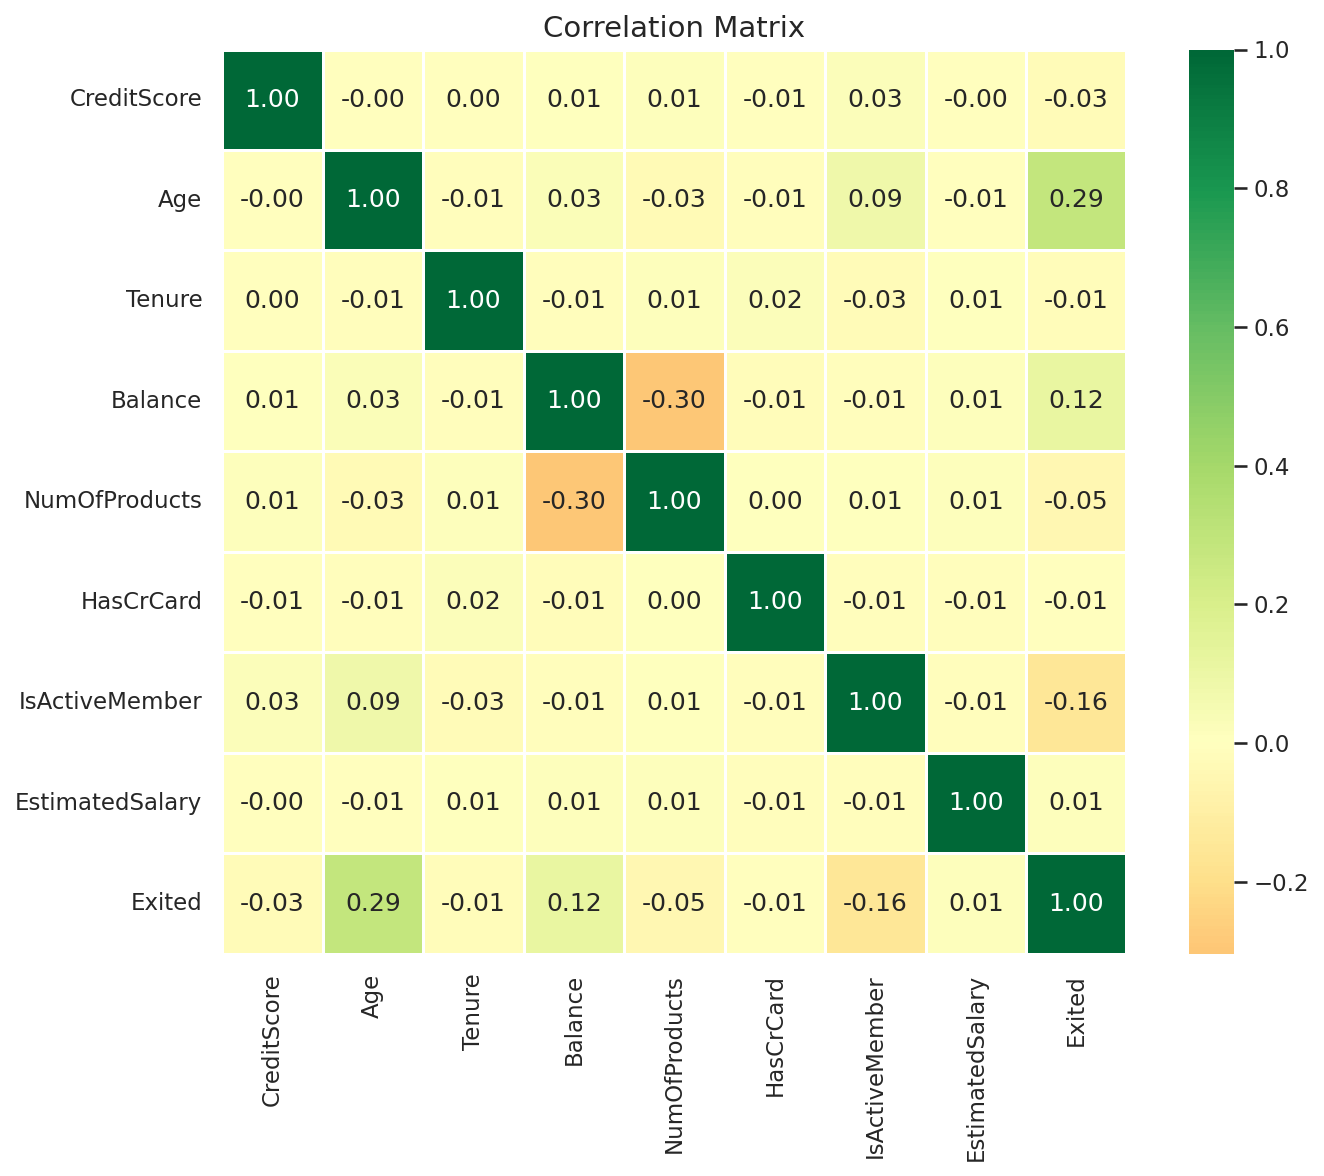

Chart 7 


In [ ]:
# Correlation heatmap
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                'EstimatedSalary', 'Exited']

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)

plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('b_chart7_correlation.png', bbox_inches='tight')
plt.show()
print("Chart 7 ")

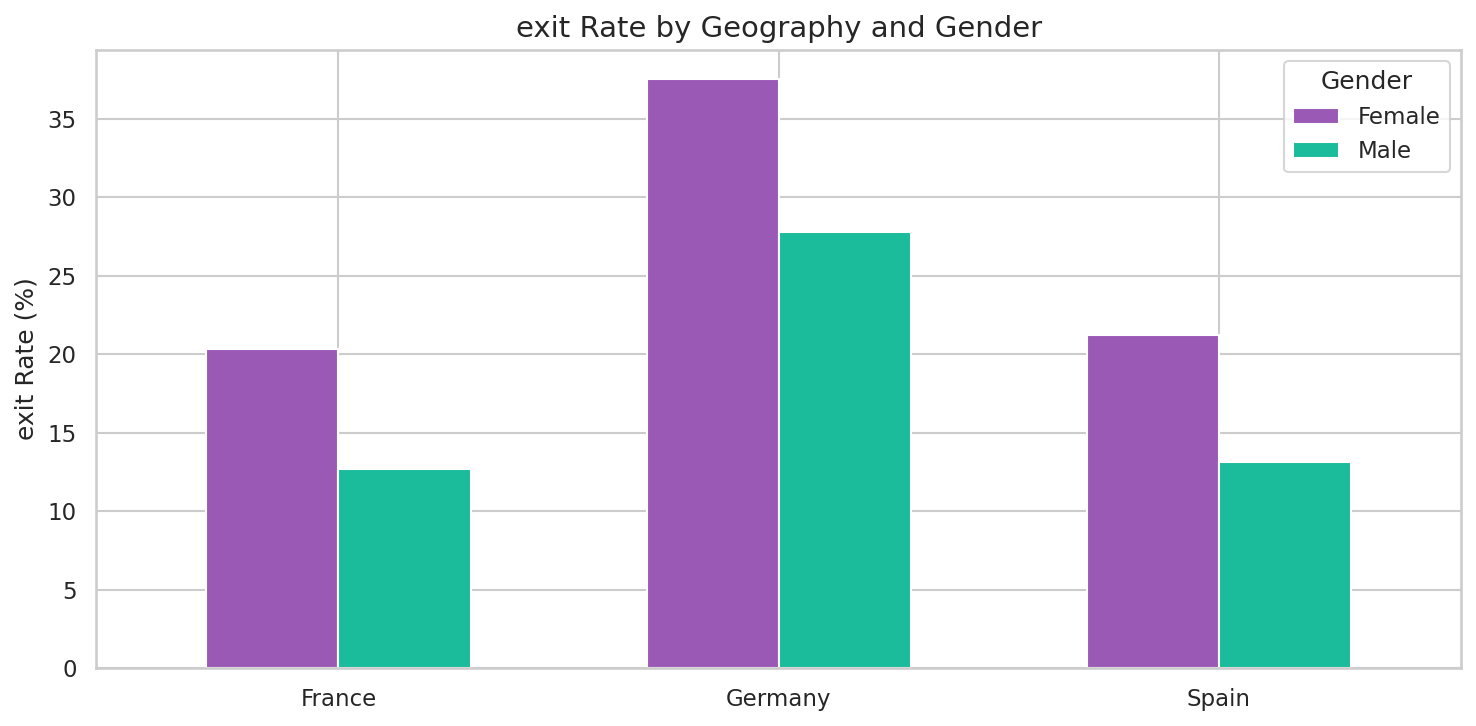

Chart 8 


In [ ]:
pivot = df.groupby(['Geography', 'Gender'])['Exited'].mean() * 100
pivot = pivot.unstack()

pivot.plot(kind='bar', figsize=(10, 5),
           color=['#9b59b6', '#1abc9c'],
           edgecolor='white', width=0.6)

plt.title('exit Rate by Geography and Gender', fontsize=14)
plt.ylabel('exit Rate (%)')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('b_chart8_geo_gender.png', bbox_inches='tight')
plt.show()
print("Chart 8 ")

In [ ]:
import pandas as pd

insights = {
    'Finding': [
        'Overall Churn Rate',
        'Highest Churn Country',
        'Highest Risk Age Group',
        'Safest Age Group',
        'Product Sweet Spot',
        'Dangerous Product Count',
        'Active vs Inactive',
        'Gender Pattern',
        'High Value Customers Lost',
        'Revenue at Risk'
    ],
    'Insight': [
        '20.37% customers bank chhod gaye',
        'Germany mein 32.44% churn — France/Spain se 2x zyada',
        '51-60 age group mein 56.21% churn — majority chhod rahe hain',
        'Under 30 age group sirf 7.56% churn — sabse loyal',
        '2 products wale customers sirf 7.58% churn karte hain',
        '4 products wale 100% churn — sab chhod gaye',
        'Inactive members 26.85% churn vs Active 14.27% — almost 2x',
        'Teeno countries mein Female churn Male se zyada',
        '718 high value customers churned — Age 41-60, Balance 100K+',
        '6.75 Crore revenue at risk — 1 product high value customers'
    ],
    'Business Recommendation': [
        'Customer retention program launch karo immediately',
        'Germany operations investigate karo — local competitor ya service issue',
        '51-60 age group ke liye special loyalty program banana chahiye',
        'Young customers ko early engage karo — loyalty long term milegi',
        '1 product customers ko 2nd product offer karo — churn 73% kam hoga',
        '3-4 products wale customers ka experience review karo — complexity kam karo',
        'Inactive customers ke liye re-engagement campaign chalao',
        'Female customers ke liye targeted retention offers banana chahiye',
        'High value churned customers ko personally contact karo',
        '1 product high value customers ko priority mein rakho — 2nd product offer karo'
    ],
    'Data Source': [
        'SQL Query 1',
        'SQL Query 2',
        'SQL Query 3',
        'SQL Query 3',
        'SQL Query 7',
        'SQL Query 7',
        'SQL Query 6',
        'EDA Chart 8',
        'SQL Query 8',
        'Revenue at Risk Query'
    ]
}

df_insights = pd.DataFrame(insights)
df_insights.to_excel('Insights_Report.xlsx', index=False)
print("Insights report ")

Insights report 
